<a href="https://colab.research.google.com/github/shagun53/ShagunGarg53/blob/main/multiple_linear_regression_student_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
dataset=pd.read_csv('student_dataset_10000_rows.csv')
x=dataset.iloc[:,:-2].values
y=dataset.iloc[:,-2].values

In [28]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(missing_values=np.nan,strategy='mean')
imputer.fit(x[:,1:6])
x[:,1:6]=imputer.transform(x[:,1:6])

In [29]:
print(dataset.isnull().sum())

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=0)

In [31]:
print(x_train)

[[ 6 70  4  9  2 55]
 [ 2 42  8  6 18 37]
 [ 9 57  8  6  8 41]
 ...
 [ 5 89  5  7  8 38]
 [ 8 56  9  5  3 90]
 [ 6 66  9  9 15 77]]


In [32]:
print(x_test)

[[10 67  6  1 13 72]
 [ 6 95  6  1 15 81]
 [ 7 82  8  6  2 76]
 ...
 [ 1 43  4  5 20 67]
 [10 83  7  8 11 93]
 [ 9 85  7 11  2 78]]


In [33]:
print(y_train)

[ 66.29  81.45  68.64 ...  61.92 100.   100.  ]


In [34]:
print(y_test)

[100.   100.    94.68 ...  80.36 100.   100.  ]


In [35]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [36]:
y_pred = regressor.predict(x_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))
print(y_pred)

[[104.87 100.  ]
 [103.84 100.  ]
 [ 88.63  94.68]
 ...
 [ 76.18  80.36]
 [107.21 100.  ]
 [ 89.85 100.  ]]
[104.87 103.84  88.63 ...  76.18 107.21  89.85]


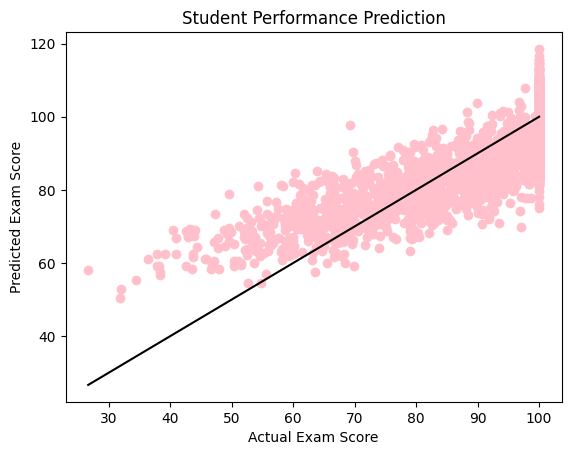

In [37]:
plt.scatter(y_test, y_pred, color='pink')
plt.plot(
[min(y_test), max(y_test)],
[min(y_test), max(y_test)],
color='black'
)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Student Performance Prediction")
plt.show()

In [38]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6645610018442393